In [13]:
pip install accelerate>=0.26.0 transformers[torch]

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\AarushiGarg\Desktop\crying\infant_audio_env\Scripts\python.exe -m pip install --upgrade pip' command.


In [3]:
# Activate your environment
conda activate infant_audio_env

# Install missing dependencies
pip install datasets transformers torch torchaudio accelerate

# If using GPU
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# Verify installation
python -c "from datasets import Dataset; print('✅ Datasets installed')"

SyntaxError: invalid syntax (337022681.py, line 2)

In [1]:
import os
import numpy as np
import librosa
import tensorflow as tf
import tensorflow_hub as hub
from transformers import (
    Wav2Vec2ForSequenceClassification,
    Wav2Vec2FeatureExtractor,
    Trainer,
    TrainingArguments,
)
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
from datasets import Dataset as HFDataset
import warnings
warnings.filterwarnings('ignore')

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# ============================================================
# Configuration
# ============================================================
CLASS_NAMES = ['cry', 'scream', 'norm']
NUM_CLASSES = len(CLASS_NAMES)
SAMPLE_RATE = 16000
MAX_LENGTH = 5 * SAMPLE_RATE  # 5 seconds max
DATA_DIR = 'C:/Users/AarushiGarg/Desktop/crying/data'

In [3]:
# ============================================================
# Data Loading with Padding/Truncation
# ============================================================
def load_audio_files(data_dir, max_length=MAX_LENGTH):
    """Load audio files with consistent length."""
    data = []
    labels = []
    file_paths = []
    
    for label_idx, label in enumerate(CLASS_NAMES):
        folder = os.path.join(data_dir, label)
        if not os.path.exists(folder):
            print(f"Warning: Folder {folder} not found")
            continue
            
        for file in os.listdir(folder):
            if file.endswith('.wav'):
                path = os.path.join(folder, file)
                try:
                    signal, sr = librosa.load(path, sr=SAMPLE_RATE)
                    
                    # Pad or truncate to fixed length
                    if len(signal) < max_length:
                        signal = np.pad(signal, (0, max_length - len(signal)))
                    else:
                        signal = signal[:max_length]
                    
                    data.append(signal)
                    labels.append(label_idx)
                    file_paths.append(path)
                except Exception as e:
                    print(f"Error loading {path}: {e}")
    
    return np.array(data), np.array(labels), file_paths

print("Loading audio files...")
X, y, paths = load_audio_files(DATA_DIR)
print(f"Loaded {len(X)} samples")
print(f"Class distribution: {dict(zip(CLASS_NAMES, [np.sum(y == i) for i in range(NUM_CLASSES)]))}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Loading audio files...
Loaded 196 samples
Class distribution: {'cry': np.int64(56), 'scream': np.int64(72), 'norm': np.int64(68)}


In [4]:
# ============================================================
# Compute Class Weights
# ============================================================
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weights_dict}")

Class weights: {0: np.float64(1.1555555555555554), 1: np.float64(0.9122807017543859), 2: np.float64(0.9629629629629629)}


In [5]:
# ============================================================
# Approach 1: YAMNet Embeddings + Custom Classifier
# ============================================================
print("\n" + "="*60)
print("Approach 1: YAMNet Embeddings + Custom Classifier")
print("="*60)

# Load YAMNet
import tensorflow_hub as hub
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

def extract_yamnet_embeddings(audio_array):
    """Extract YAMNet embeddings (1024-dim) for each audio sample."""
    embeddings_list = []
    for audio in audio_array:
        waveform = tf.convert_to_tensor(audio, dtype=tf.float32)
        scores, embeddings, spectrogram = yamnet_model(waveform)
        # Average embeddings across time
        avg_embedding = tf.reduce_mean(embeddings, axis=0).numpy()
        embeddings_list.append(avg_embedding)
    return np.array(embeddings_list)

print("Extracting YAMNet embeddings...")
X_train_yamnet = extract_yamnet_embeddings(X_train)
X_test_yamnet = extract_yamnet_embeddings(X_test)
print(f"Embedding shape: {X_train_yamnet.shape}")

# Simple classifier on top of YAMNet embeddings
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

yamnet_classifier = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=500,
    early_stopping=True,
    random_state=42
)
yamnet_classifier.fit(X_train_yamnet, y_train)

y_pred_yamnet = yamnet_classifier.predict(X_test_yamnet)
y_prob_yamnet = yamnet_classifier.predict_proba(X_test_yamnet)

print("\nYAMNet + MLP Results:")
print(classification_report(y_test, y_pred_yamnet, target_names=CLASS_NAMES))


Approach 1: YAMNet Embeddings + Custom Classifier



Extracting YAMNet embeddings...
Embedding shape: (156, 1024)

YAMNet + MLP Results:
              precision    recall  f1-score   support

         cry       0.69      1.00      0.81        11
      scream       0.83      0.67      0.74        15
        norm       0.83      0.71      0.77        14

    accuracy                           0.78        40
   macro avg       0.78      0.79      0.77        40
weighted avg       0.79      0.78      0.77        40



In [6]:
# ============================================================
# Approach 2: Fine-tune Wav2Vec2 for Your Classes
# ============================================================
print("\n" + "="*60)
print("Approach 2: Fine-tuned Wav2Vec2")
print("="*60)

# Custom Dataset for Wav2Vec2
class AudioDataset(Dataset):
    def __init__(self, audio_data, labels, feature_extractor, max_length=MAX_LENGTH):
        self.audio_data = audio_data
        self.labels = labels
        self.feature_extractor = feature_extractor
        self.max_length = max_length
    
    def __len__(self):
        return len(self.audio_data)
    
    def __getitem__(self, idx):
        audio = self.audio_data[idx]
        inputs = self.feature_extractor(
            audio,
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
            padding="max_length",
            max_length=self.max_length,
            truncation=True
        )
        return {
            'input_values': inputs.input_values.squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }
print("🔄 Loading Wav2Vec2...")
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base")
model_wav2vec = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=NUM_CLASSES,
    problem_type="single_label_classification"
)
model_wav2vec.freeze_feature_encoder()


Approach 2: Fine-tuned Wav2Vec2
🔄 Loading Wav2Vec2...


Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
# Load pre-trained Wav2Vec2 and modify for 3 classes

# Freeze feature extractor layers for faster training
model_wav2vec.freeze_feature_encoder()

# Create datasets
train_dataset = AudioDataset(X_train, y_train, feature_extractor)
test_dataset = AudioDataset(X_test, y_test, feature_extractor)

# Training arguments
from transformers import TrainingArguments
training_args = TrainingArguments(
    output_dir="./wav2vec2_infant_cry",
    eval_strategy="epoch",           
    save_strategy="epoch",
    learning_rate=1e-4,
    per_device_train_batch_size=2,   
    per_device_eval_batch_size=2,
    num_train_epochs=5,              
    warmup_ratio=0.1,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    push_to_hub=False,
    fp16=torch.cuda.is_available(),
    report_to=None,                  
)

In [9]:

# Custom compute metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = np.mean(predictions == labels)
    return {"accuracy": accuracy}

# Trainer with class weights
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        weight = torch.tensor(
            [class_weights_dict[i] for i in range(NUM_CLASSES)],
            device=logits.device,
            dtype=logits.dtype
        )
        loss_fn = nn.CrossEntropyLoss(weight=weight)
        loss = loss_fn(logits, labels)
        
        return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    model=model_wav2vec,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("Fine-tuning Wav2Vec2...")
trainer.train()

# Evaluate
print("\nWav2Vec2 Fine-tuned Results:")
model_wav2vec.eval()

y_pred_wav2vec = []
y_prob_wav2vec = []

with torch.no_grad():
    for i in range(len(X_test)):
        inputs = feature_extractor(
            X_test[i],
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
            padding="max_length",
            max_length=MAX_LENGTH,
            truncation=True
        )
        outputs = model_wav2vec(inputs.input_values)
        probs = torch.softmax(outputs.logits, dim=-1).numpy()[0]
        y_prob_wav2vec.append(probs)
        y_pred_wav2vec.append(np.argmax(probs))

y_pred_wav2vec = np.array(y_pred_wav2vec)
y_prob_wav2vec = np.array(y_prob_wav2vec)

print(classification_report(y_test, y_pred_wav2vec, target_names=CLASS_NAMES))

Fine-tuning Wav2Vec2...


Epoch,Training Loss,Validation Loss,Accuracy
1,1.292200,1.200098,0.350000
2,1.125100,1.098129,0.350000
3,1.043200,1.246833,0.350000
4,1.187300,1.128868,0.350000
5,1.115900,1.101228,0.350000



Wav2Vec2 Fine-tuned Results:
              precision    recall  f1-score   support

         cry       0.00      0.00      0.00        11
      scream       0.00      0.00      0.00        15
        norm       0.35      1.00      0.52        14

    accuracy                           0.35        40
   macro avg       0.12      0.33      0.17        40
weighted avg       0.12      0.35      0.18        40




Approach 3: Ensemble (YAMNet + Fine-tuned Wav2Vec2)

Ensemble Results:
              precision    recall  f1-score   support

         cry       1.00      0.45      0.62        11
      scream       0.00      0.00      0.00        15
        norm       0.38      0.93      0.54        14

    accuracy                           0.45        40
   macro avg       0.46      0.46      0.39        40
weighted avg       0.41      0.45      0.36        40



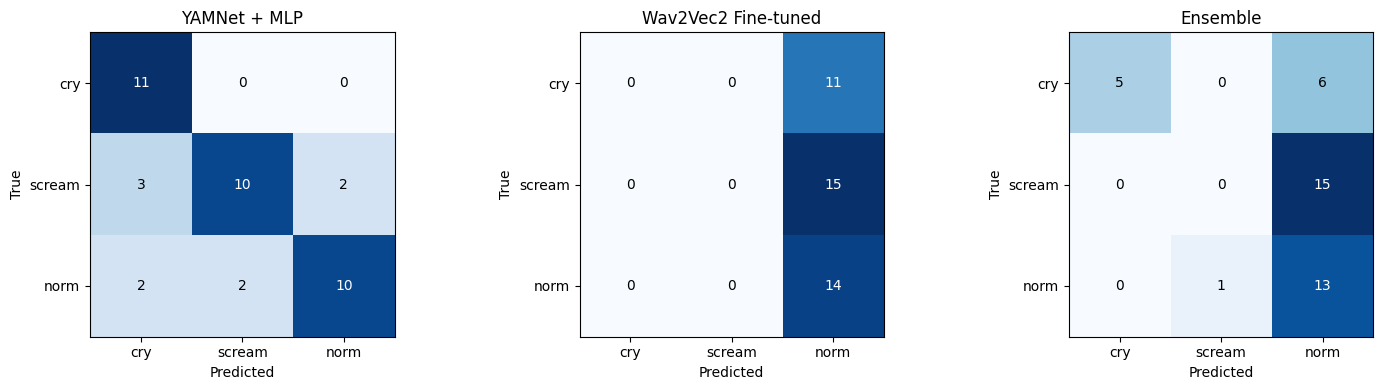

In [10]:
# ============================================================
# Approach 3: Proper Ensemble
# ============================================================
print("\n" + "="*60)
print("Approach 3: Ensemble (YAMNet + Fine-tuned Wav2Vec2)")
print("="*60)

def ensemble_predict(yamnet_probs, wav2vec_probs, weights=(0.4, 0.6)):
    """Weighted ensemble of two models."""
    combined = weights[0] * yamnet_probs + weights[1] * wav2vec_probs
    return np.argmax(combined, axis=1), combined

y_pred_ensemble, y_prob_ensemble = ensemble_predict(y_prob_yamnet, y_prob_wav2vec)

print("\nEnsemble Results:")
print(classification_report(y_test, y_pred_ensemble, target_names=CLASS_NAMES))

# ============================================================
# Visualization
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ('YAMNet + MLP', y_pred_yamnet),
    ('Wav2Vec2 Fine-tuned', y_pred_wav2vec),
    ('Ensemble', y_pred_ensemble)
]

for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
    ax.set_title(name)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    
    # Add text annotations
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                   color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()



In [11]:
# ============================================================
# Save Models
# ============================================================
import joblib

joblib.dump(yamnet_classifier, 'yamnet_classifier.joblib')
model_wav2vec.save_pretrained('./wav2vec2_infant_cry/final')
feature_extractor.save_pretrained('./wav2vec2_infant_cry/final')
print("\nModels saved!")



Models saved!


In [13]:
pip install audiomentations


   -------------------- ------------------- 2/4 [numpy-minmax]
   ------------------------------ --------- 3/4 [audiomentations]
   ------------------------------ --------- 3/4 [audiomentations]
   ------------------------------ --------- 3/4 [audiomentations]
   ------------------------------ --------- 3/4 [audiomentations]
   ------------------------------ --------- 3/4 [audiomentations]
   ------------------------------ --------- 3/4 [audiomentations]
   ------------------------------ --------- 3/4 [audiomentations]
   ------------------------------ --------- 3/4 [audiomentations]
   ---------------------------------------- 4/4 [audiomentations]

Note: you may need to restart the kernel to use updated packages.


In [14]:
import audiomentations as AA

augment = AA.Compose([
    AA.AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
    AA.TimeStretch(min_rate=0.8, max_rate=1.2, p=0.5),
    AA.PitchShift(min_semitones=-4, max_semitones=4, p=0.5),
    AA.Shift(min_shift=-0.5, max_shift=0.5, p=0.5),
])

def augment_dataset(X, y, num_augments=3):
    X_aug, y_aug = list(X), list(y)
    for audio, label in zip(X, y):
        for _ in range(num_augments):
            augmented = augment(samples=audio, sample_rate=SAMPLE_RATE)
            X_aug.append(augmented)
            y_aug.append(label)
    return np.array(X_aug), np.array(y_aug)

X_train_aug, y_train_aug = augment_dataset(X_train, y_train)
